In [2]:
import torch 
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from torchinfo import summary

from torchvision import transforms
import torchvision.models.video as video_models
import torchvision.models as models
from torchvision.datasets import DatasetFolder

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

import os
import shutil
import random
import cv2
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm
from PIL import Image

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
# shutil.rmtree("/kaggle/working/data_train")
# shutil.rmtree("/kaggle/working/val")

In [4]:
link = "/kaggle/working/data"
os.makedirs(link, exist_ok=True)

train_link = "/kaggle/working/data/train"
os.makedirs(train_link, exist_ok=True)

val_link = "/kaggle/working/data/val"
os.makedirs(val_link, exist_ok=True)

In [4]:
base_dir = "/kaggle/input/realistic-action-recognition-ucf50/UCF50"

train_dir = "/kaggle/working/data/train"
val_dir = "/kaggle/working/data/val"

split_ratio = 0.9

for in_dir in tqdm(os.listdir(base_dir)):
    dir_path = os.path.join(base_dir, in_dir)

    train_in_dir = os.path.join(train_dir, in_dir)
    os.makedirs(train_in_dir, exist_ok=True)
    
    val_in_dir = os.path.join(val_dir, in_dir)
    os.makedirs(val_in_dir, exist_ok=True)

    videos = os.listdir(dir_path)
    random.shuffle(videos)

    split_idx = int(len(videos) * split_ratio)
    
    train_set = videos[:split_idx]
    val_set = videos[split_idx:]

    for video in train_set:
        full_video_path = os.path.join(dir_path, video)
        train_video_path = os.path.join(train_in_dir, video)
        shutil.copy(full_video_path, train_video_path)

    for video in val_set:
        full_video_path = os.path.join(dir_path, video)
        val_video_path = os.path.join(val_in_dir, video)
        shutil.copy(full_video_path, val_video_path)

100%|██████████| 50/50 [01:29<00:00,  1.80s/it]


In [5]:
def load_video(path, num_frames=16, size=(128, 128), transform=None):
    frames = []
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_length = np.linspace(0, total_frames-1, num_frames, dtype=int)

    for i in frames_length:
        cap.set(cv2.CAP_PROP_FRAME_COUNT, i)
        ret, frame = cap.read()
        if not ret:
            break
            
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)
        frame = torch.tensor(frame).permute(2, 0, 1) / 255.0

        if transform is not None:
            frame = transform(frame)
            
        frames.append(frame)

    cap.release()
    while len(frames) < num_frames:
        frames.append(frames[-1])

    
    return torch.stack(frames, dim=0)
    # return torch.stack(frames, dim=1)

In [6]:
train_transformer = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomCrop((128, 128)),   
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),                        
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomCrop(128)
])

val_transformer = transforms.Compose([
    transforms.Resize((128, 128))
])

In [7]:
train_link = "/kaggle/working/data/train"
train_data = DatasetFolder(root=train_link, loader=load_video, extensions=("mp4", "avi"), transform=train_transformer)

val_link = "/kaggle/working/data/val"
val_data = DatasetFolder(root=val_link, loader=load_video, extensions=("mp4", "avi"), transform=val_transformer)

In [8]:
len(train_data), len(val_data)

(5993, 688)

In [9]:
x, y = train_data[0]
x.shape, y

(torch.Size([16, 3, 128, 128]), 0)

In [10]:
x, y = train_data[0]
x, y

(tensor([[[[0.8078, 0.8431, 0.2902,  ..., 0.9843, 0.9843, 0.9843],
           [0.7608, 0.9451, 0.3529,  ..., 0.9843, 0.9843, 0.9843],
           [0.9373, 0.9098, 0.7098,  ..., 0.9843, 0.9843, 0.9843],
           ...,
           [0.2863, 0.2941, 0.3451,  ..., 0.2314, 0.2157, 0.1843],
           [0.3176, 0.3098, 0.3333,  ..., 0.2157, 0.2118, 0.1843],
           [0.2235, 0.2235, 0.2078,  ..., 0.1176, 0.1490, 0.1529]],
 
          [[0.8314, 0.8667, 0.3137,  ..., 0.9843, 0.9843, 0.9843],
           [0.7843, 0.9647, 0.3765,  ..., 0.9843, 0.9843, 0.9843],
           [0.9608, 0.9333, 0.7333,  ..., 0.9843, 0.9843, 0.9843],
           ...,
           [0.3137, 0.3216, 0.3725,  ..., 0.3176, 0.3020, 0.2706],
           [0.3451, 0.3373, 0.3608,  ..., 0.3020, 0.2980, 0.2706],
           [0.2510, 0.2510, 0.2353,  ..., 0.2039, 0.2353, 0.2392]],
 
          [[0.8353, 0.8706, 0.3177,  ..., 0.9843, 0.9843, 0.9843],
           [0.7882, 0.9686, 0.3804,  ..., 0.9843, 0.9843, 0.9843],
           [0.9647, 0.93

In [11]:
names = train_data.classes
len(names)

50

In [13]:
def output(data, limit, names):
    for i, (x, y) in enumerate(data):
        x = x[0, :, :, :].permute(1, 2, 0).cpu().numpy()
        plt.imshow(x)
        name = names[y]
        plt.title(name)
        plt.axis("off")
        plt.show()

        if i+1 == limit:
            break
        

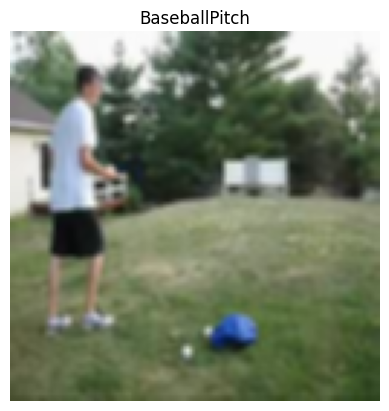

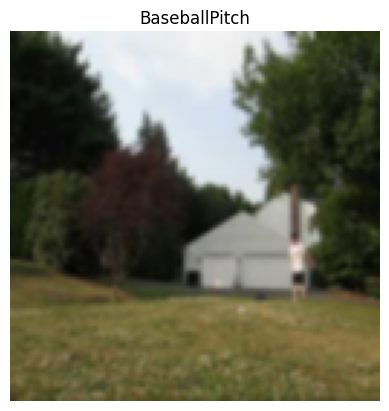

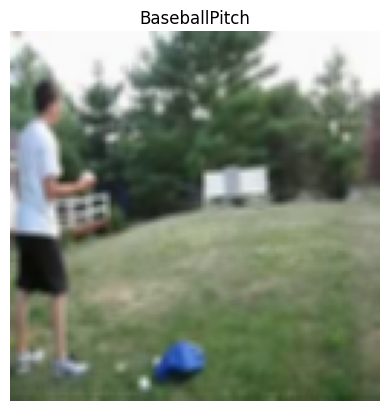

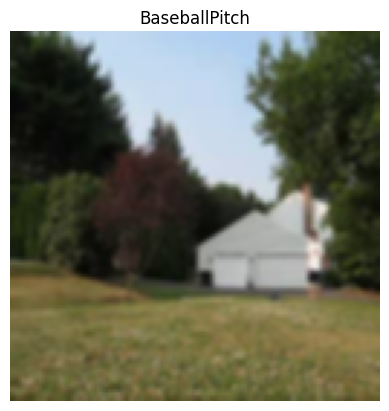

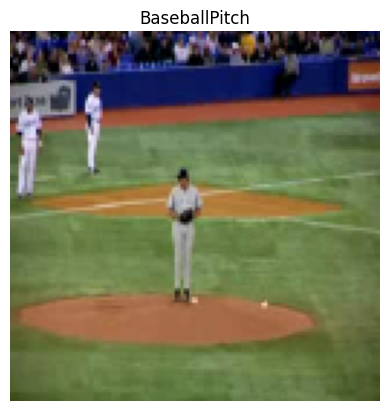

In [14]:
output(train_data, 5, names)

In [14]:
batch_size = 64

train_dl = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_data, batch_size=batch_size, shuffle=False)

In [15]:
x, y = next(iter(train_dl))
x.shape, y.shape

(torch.Size([64, 16, 3, 128, 128]), torch.Size([64]))

In [16]:
class TeacherNet(nn.Module):
    def __init__(self, out_channels=50):
        super().__init__()

        self.model = video_models.r3d_18(weights="KINETICS400_V1")
        self.model.fc = nn.Linear(512, out_channels)

    def forward(self, x):
        out = self.model(x)
        # out = F.softmax(out, dim=1)
        return out 

    def predict(self, x):
        self.eval()

        if x.shape == 4:
            x = x.unsqueeze(0)

        with torch.no_grad(): 
            out = self.forward(x)
        out = F.softmax(out, dim=1)
        res = torch.argmax(out, dim=1).item()
        return res 

In [18]:
model = TeacherNet()
tensor = torch.randn(1, 3, 32, 128, 128)

out = model(tensor)
out.shape

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 148MB/s]  


torch.Size([1, 50])

In [19]:
model = TeacherNet()
tensor = torch.randn(1, 3, 32, 128, 128)

out = model.predict(tensor)
out

11

In [20]:
summary(model, input_data=torch.randn(1, 3, 16, 128, 128))

Layer (type:depth-idx)                        Output Shape              Param #
TeacherNet                                    [1, 50]                   --
├─VideoResNet: 1-1                            [1, 50]                   --
│    └─BasicStem: 2-1                         [1, 64, 16, 64, 64]       --
│    │    └─Conv3d: 3-1                       [1, 64, 16, 64, 64]       28,224
│    │    └─BatchNorm3d: 3-2                  [1, 64, 16, 64, 64]       128
│    │    └─ReLU: 3-3                         [1, 64, 16, 64, 64]       --
│    └─Sequential: 2-2                        [1, 64, 16, 64, 64]       --
│    │    └─BasicBlock: 3-4                   [1, 64, 16, 64, 64]       221,440
│    │    └─BasicBlock: 3-5                   [1, 64, 16, 64, 64]       221,440
│    └─Sequential: 2-3                        [1, 128, 8, 32, 32]       --
│    │    └─BasicBlock: 3-6                   [1, 128, 8, 32, 32]       672,512
│    │    └─BasicBlock: 3-7                   [1, 128, 8, 32, 32]       885

In [21]:
model.to(device)

TeacherNet(
  (model): VideoResNet(
    (stem): BasicStem(
      (0): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (conv2): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (relu): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv1): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 

In [22]:
def train(model, train_dl, val_dl, optimizer, loss_fn, accuracy_score, epochs, device):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss = 0.0
        train_acc = 0.0
        model.train()

        for x, y in tqdm(train_dl):
            x = x.to(device).float()
            x = x.permute(0, 2, 1, 3, 4)
            y = y.to(device)

            optimizer.zero_grad()
            out = model(x)

            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

            train_loss+=loss.item()

            out = torch.argmax(out, dim=1).detach().cpu().numpy()
            y = y.cpu().numpy()
            acc = accuracy_score(out, y)
            train_acc += acc

        val_loss = 0.0
        val_acc = 0.0
        model.eval()

        with torch.no_grad():
            for x, y in tqdm(val_dl):
                x = x.to(device).float()
                x = x.permute(0, 2, 1, 3, 4)
                y = y.to(device)

                out = model(x)
                loss = loss_fn(out, y)
                val_loss += loss.item()

                out = torch.argmax(out, dim=1).detach().cpu().numpy()
                y = y.cpu().numpy()

                acc = accuracy_score(out, y)
                val_acc += acc


        total_train_loss = train_loss / len(train_dl)
        total_train_acc = train_acc / len(train_dl)

        total_val_loss = val_loss / len(val_dl)
        total_val_acc = val_acc / len(val_dl)

        history["train_loss"].append(total_train_loss)
        history["train_acc"].append(total_train_acc)

        history["val_loss"].append(total_val_loss)
        history["val_acc"].append(total_val_acc)

        print(f"Epoch: {epoch+1} | train_loss: {total_train_loss:.4f} | train_acc: {total_train_acc:.4f} | val_loss: {total_val_loss:.4f} | val_acc: {total_val_acc:.4f}")
                
    return history 

        
            

In [34]:
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
epochs = 20

In [35]:
history = train(model, train_dl, val_dl, optimizer, loss_fn, accuracy_score, epochs, device)

100%|██████████| 22/22 [00:17<00:00,  1.26it/s]


Epoch: 1 | train_loss: 1.3534 | train_acc: 0.6362 | val_loss: 2.1958 | val_acc: 0.4801


100%|██████████| 22/22 [00:17<00:00,  1.25it/s]


Epoch: 2 | train_loss: 0.5255 | train_acc: 0.8486 | val_loss: 0.5985 | val_acc: 0.8139


100%|██████████| 22/22 [00:17<00:00,  1.26it/s]


...

Epoch: 18 | train_loss: 0.0193 | train_acc: 0.9942 | val_loss: 0.3245 | val_acc: 0.9062


100%|██████████| 22/22 [00:17<00:00,  1.27it/s]


Epoch: 19 | train_loss: 0.0180 | train_acc: 0.9943 | val_loss: 0.3273 | val_acc: 0.9176


100%|██████████| 22/22 [00:17<00:00,  1.25it/s]

Epoch: 20 | train_loss: 0.0645 | train_acc: 0.9822 | val_loss: 0.4616 | val_acc: 0.8835


In [36]:
torch.save(model.state_dict(), "teacher_model.pt")

In [39]:
def output_metrics(history, name):
    plt.plot(history[f"train_{name}"], label="Training set")
    plt.plot(history[f"val_{name}"], label="Validation set")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.show()

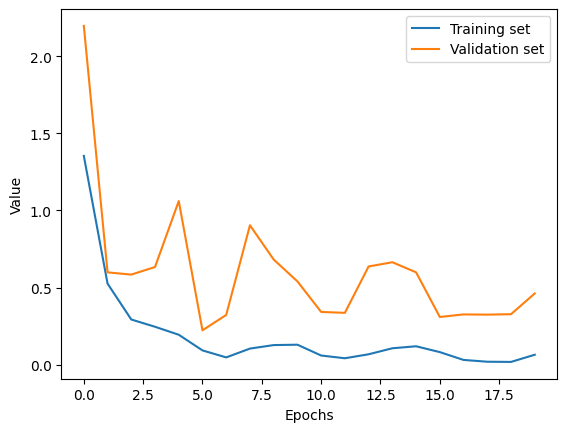

In [38]:
output_metrics(history, "loss")

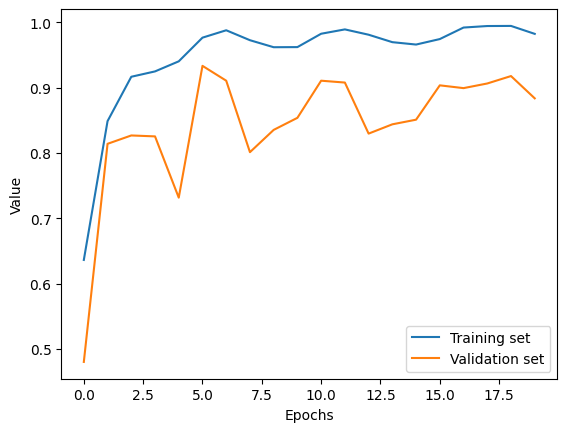

In [39]:
output_metrics(history, "acc")

In [17]:
t_model = TeacherNet()
link = "/kaggle/input/t-model-weights/teacher_model.pt"
t_model.load_state_dict(torch.load(link, map_location=device))
t_model.to(device)

TeacherNet(
  (model): VideoResNet(
    (stem): BasicStem(
      (0): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (conv2): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (relu): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv1): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 

In [19]:
def check(data, limit, model):
    for i, (x, y) in enumerate(val_data):
        x_pred = x.unsqueeze(0).to(device)
        x_pred = x_pred.permute(0, 2, 1, 3, 4)
        
        res = model.predict(x_pred)
        x_to_display = x[0, :, :, :].permute(1, 2, 0).cpu().numpy()
        plt.imshow(x_to_display)
        text = f"Real: {y} | Predicted: {res}"
        plt.title(text)
        plt.show()
    
        if i+1 == 5:
            break

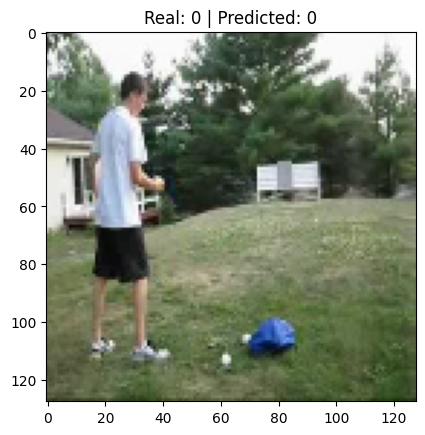

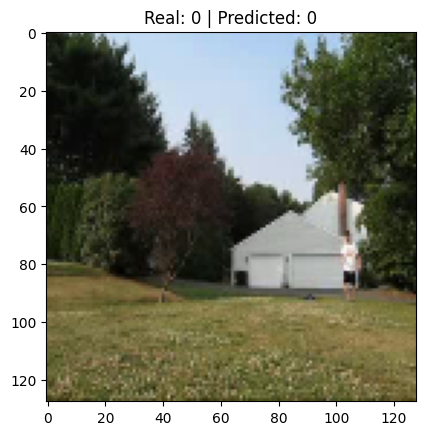

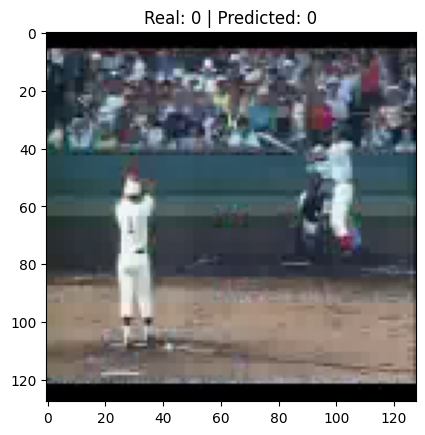

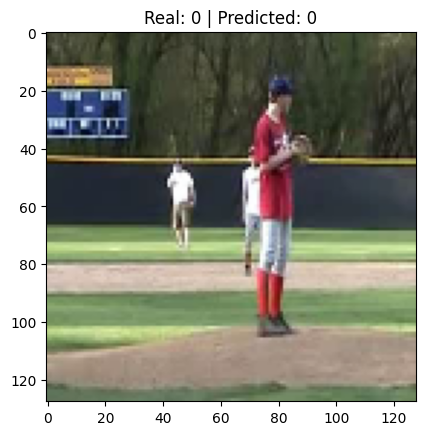

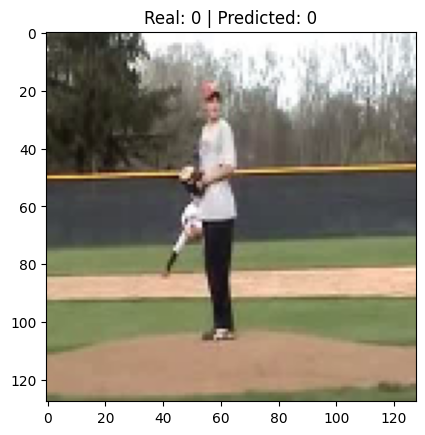

In [25]:
check(val_data, 5, t_model)

In [20]:
def video2tensor(link, transformer, num_frames):
    cap = cv2.VideoCapture(link)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {link}")

    
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
    
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame)     
        img = transformer(img)             
        frames.append(img)
    
    num_frames = 16
    T = len(frames)
    
    if T >= num_frames:
        indices = torch.linspace(0, T - 1, num_frames).long()
        frames = [frames[i] for i in indices]
    else:
        while len(frames) < num_frames:
            frames.append(frames[-1])
    
    video = torch.stack(frames, dim=1)  
    video = video.unsqueeze(0)           
    
    return video
    

In [36]:
link = "/kaggle/working/data/val/Diving/v_Diving_g05_c04.avi"
transformer = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),         
])
num_frames = 16

tensor = video2tensor(link, transformer, num_frames)
tensor = tensor.to(device)
res = t_model.predict(tensor)
print(f"Prediction: {names[int(res)]}")



Prediction: Diving


100%|██████████| 22/22 [00:17<00:00,  1.27it/s]


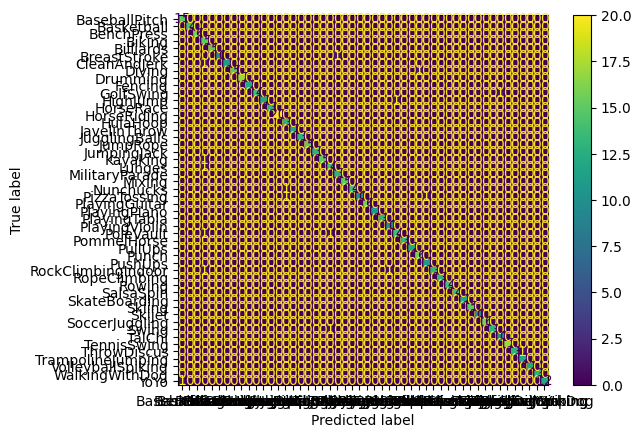

In [59]:
y_preds = []
y_trues = []


model.eval()
with torch.no_grad():
    for x, y in tqdm(val_dl):
        x = x.to(device)
        y = y.to(device)

        x = x.permute(0, 2, 1, 3, 4)

        out = t_model(x)
        y_pred = torch.argmax(out, dim=1)
        
        y_preds.extend(y_pred.cpu().numpy())
        y_trues.extend(y.cpu().numpy())

y_preds = np.array(y_preds)
y_trues = np.array(y_trues)

ConfusionMatrixDisplay.from_predictions(y_trues, y_preds, labels=np.arange(len(names)), display_labels=names)        

In [21]:
class TemporalAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):  # x: (B, F, D)
        w = torch.softmax(self.attn(x), dim=1)  # (B, F, 1)
        return (x * w).sum(dim=1)                # (B, D)


In [22]:
tensor = torch.randn(32, 16, 512)
ta_block = TemporalAttention(512)

out = ta_block(tensor)
out.shape

torch.Size([32, 512])

In [23]:
tensor = torch.randn(32, 16, 512)
layer = nn.Linear(512, 1)

out = layer(tensor)
print(out.shape)

out = torch.softmax(out, dim=1)
print(out.shape)

out = out * tensor
print(out.shape)

out = out.sum(dim=1)
print(out.shape)

torch.Size([32, 16, 1])
torch.Size([32, 16, 1])
torch.Size([32, 16, 512])
torch.Size([32, 512])


In [26]:
class StudentNet(nn.Module):
    def __init__(self, num_layers=1, input_size=512, hidden_size=256, num_classes=50, bidirectional=True):
        super().__init__()

        body = models.resnet34(weights="DEFAULT")
        self.cnn = nn.Sequential(*list(body.children())[:-2])
        self.aap = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        self.lstm = nn.LSTM(
            input_size = input_size, 
            hidden_size = hidden_size,
            num_layers = num_layers, 
            batch_first = True,
            bidirectional = True
        )

        lstm_out = hidden_size * 2 if bidirectional else hidden_size
        
        self.temporal_attn = TemporalAttention(lstm_out)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_out, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, F, C, H, W = x.shape
        x = x.reshape(B*F, C, H, W)

        out = self.cnn(x)
        out = self.aap(out)
        out = self.flatten(out)

        out = out.reshape(B, F, -1)
        lstm_out, (_, _) = self.lstm(out)
        out = self.temporal_attn(lstm_out)
        
        out = self.classifier(out)

        return out

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            out = self.forward(x)
        out = torch.softmax(out, dim=1)
        out = torch.argmax(out, dim=1)
        return out.item()

In [27]:
s_model = StudentNet()
tensor = torch.randn(1, 16, 3, 128, 128)
out = s_model(tensor)
out.shape

torch.Size([1, 50])

In [28]:
s_model = StudentNet()
tensor = torch.randn(1, 16, 3, 128, 128)
out = s_model.predict(tensor)
out

17

In [29]:
summary(s_model, input_data=torch.randn(1, 16, 3, 128, 128))

Layer (type:depth-idx)                        Output Shape              Param #
StudentNet                                    [1, 50]                   --
├─Sequential: 1-1                             [16, 512, 4, 4]           --
│    └─Conv2d: 2-1                            [16, 64, 64, 64]          9,408
│    └─BatchNorm2d: 2-2                       [16, 64, 64, 64]          128
│    └─ReLU: 2-3                              [16, 64, 64, 64]          --
│    └─MaxPool2d: 2-4                         [16, 64, 32, 32]          --
│    └─Sequential: 2-5                        [16, 64, 32, 32]          --
│    │    └─BasicBlock: 3-1                   [16, 64, 32, 32]          73,984
│    │    └─BasicBlock: 3-2                   [16, 64, 32, 32]          73,984
│    │    └─BasicBlock: 3-3                   [16, 64, 32, 32]          73,984
│    └─Sequential: 2-6                        [16, 128, 16, 16]         --
│    │    └─BasicBlock: 3-4                   [16, 128, 16, 16]         230,144

In [30]:
s_model.to(device)

StudentNet(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [32]:
def distillation_train(t_model, s_model, train_dl, val_dl, optimizer, loss_fn, kl_div, accuracy_score, epochs, device, temperature=5, alpha=0.5):
    history = {
        "train_loss": [],
        "train_acc": [],

        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss = 0.0
        train_acc = 0.0
        s_model.train()
        t_model.eval()

        for x, y in tqdm(train_dl):
            x = x.to(device).float()
            y = y.to(device)

            optimizer.zero_grad()
            s_out = s_model(x)

            if epoch > 35:
            
                with torch.no_grad():
                    x_teacher = x.permute(0, 2, 1, 3, 4)
                    t_out = t_model(x_teacher)
    
    
                hard_loss = loss_fn(s_out, y)
                soft_loss = kl_div(
                    F.log_softmax(s_out / temperature, dim=1),
                    F.softmax(t_out / temperature, dim=1)
                )
    
                loss = alpha * hard_loss + (1 - alpha) * soft_loss * (temperature**2)

            else:
                loss = loss_fn(s_out, y)
            
            train_loss += loss.item()
            loss.backward()

            out = torch.argmax(s_out, dim=1).detach().cpu().numpy()
            y = y.cpu().numpy()
            
            acc = accuracy_score(out, y)
            train_acc += acc

            optimizer.step()


        val_loss = 0.0
        val_acc = 0.0
        s_model.eval()
        with torch.no_grad():
            for x, y in tqdm(val_dl):
                x = x.to(device).float()
                y = y.to(device)
    
                out = s_model(x)
                loss = loss_fn(out, y)
                val_loss += loss.item()

                out = torch.argmax(out, dim=1).detach().cpu().numpy()
                y = y.cpu().numpy()

                acc = accuracy_score(out, y)
                val_acc += acc

        total_train_loss = train_loss / len(train_dl)
        total_train_acc = train_acc / len(train_dl)

        total_val_loss = val_loss / len(val_dl)
        total_val_acc = val_acc / len(val_dl)

        history["train_loss"].append(total_train_loss)
        history["train_acc"].append(total_train_acc)

        history["val_loss"].append(total_val_loss)
        history["val_acc"].append(total_val_acc)

        print(f"Epoch: {epoch+1} | train_loss: {total_train_loss:.4f} | train_acc: {total_train_acc:.4f} | val_loss: {total_val_loss:.4f} | val_acc: {total_val_acc:.4f}")
                
    return history  

        

In [33]:
optimizer = Adam(s_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
kl_div = nn.KLDivLoss(reduction='batchmean')
epochs = 30

In [34]:
# !!! NO DISTILLATION

history = distillation_train(t_model, s_model, train_dl, val_dl, optimizer, loss_fn, kl_div, accuracy_score, epochs, device, temperature=3, alpha=0.9)

100%|██████████| 11/11 [00:10<00:00,  1.05it/s]


Epoch: 1 | train_loss: 3.2829 | train_acc: 0.1695 | val_loss: 3.7482 | val_acc: 0.1335


100%|██████████| 11/11 [00:10<00:00,  1.04it/s]


Epoch: 2 | train_loss: 2.5936 | train_acc: 0.2895 | val_loss: 2.7257 | val_acc: 0.2637


100%|██████████| 11/11 [00:10<00:00,  1.03it/s]


...

Epoch: 28 | train_loss: 0.1210 | train_acc: 0.9676 | val_loss: 1.0746 | val_acc: 0.7973


100%|██████████| 11/11 [00:10<00:00,  1.04it/s]


Epoch: 29 | train_loss: 0.1194 | train_acc: 0.9677 | val_loss: 0.8241 | val_acc: 0.8205


100%|██████████| 11/11 [00:10<00:00,  1.04it/s]

Epoch: 30 | train_loss: 0.0852 | train_acc: 0.9761 | val_loss: 0.8429 | val_acc: 0.8229


100%|██████████| 11/11 [00:10<00:00,  1.04it/s]


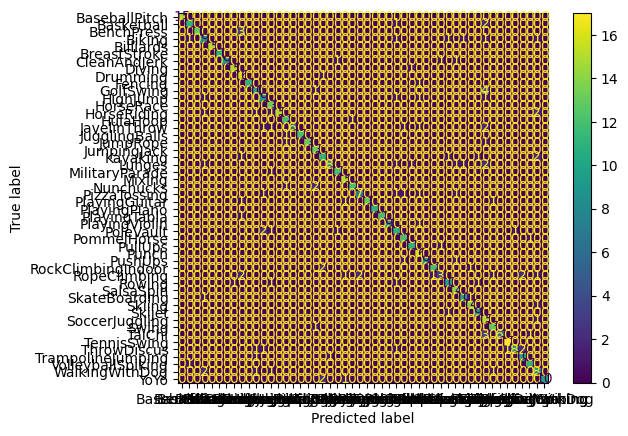

In [36]:
y_preds = []
y_trues = []


s_model.eval()
with torch.no_grad():
    for x, y in tqdm(val_dl):
        x = x.to(device)
        y = y.to(device)

        # x = x.permute(0, 2, 1, 3, 4)

        out = s_model(x)
        y_pred = torch.argmax(out, dim=1)
        
        y_preds.extend(y_pred.cpu().numpy())
        y_trues.extend(y.cpu().numpy())

y_preds = np.array(y_preds)
y_trues = np.array(y_trues)

ConfusionMatrixDisplay.from_predictions(y_trues, y_preds, labels=np.arange(len(names)), display_labels=names)        

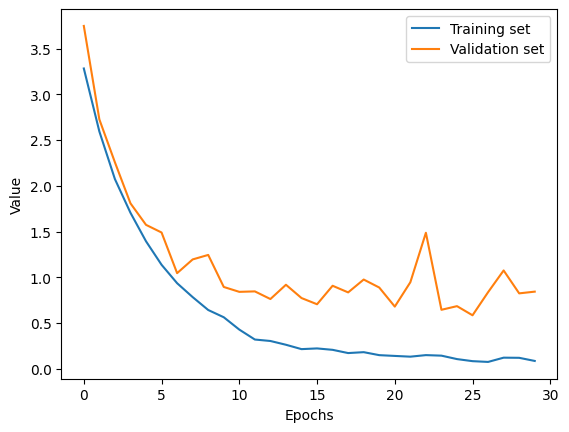

In [40]:
output_metrics(history, "loss")

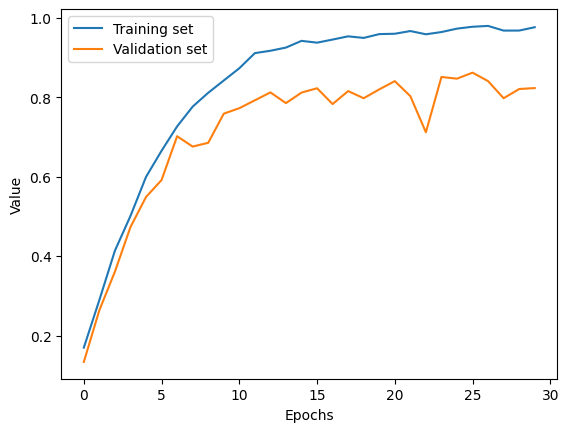

In [41]:
output_metrics(history, "acc")

In [42]:
torch.save(s_model.state_dict(), "student_model.pt")